<a href="https://colab.research.google.com/github/Ashu-42/quant_research_crypto_volatility_forecasting/blob/main/notebooks/trail_ARCH_Family_Validation_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 09 — ARCH-Family Models: Leakage-Safe Validation Comparison

This notebook builds and evaluates:

1. **GARCH(1,1)**
2. **GJR-GARCH(1,1)**
3. **EGARCH(1,1)**

The design is aligned with the deep-learning experiment:

- Daily returns are used to estimate each ARCH-family model.
- Parameters are estimated using data available through **2024-06-30 only**.
- One-step-ahead conditional variance forecasts are produced for the validation period:
  **2024-07-01 through 2025-06-30**.
- Every forecast is compared with the same next-day realized variance constructed from 15-minute returns.
- MAE, RMSE and QLIKE are calculated on the original realized-variance scale.
- Metrics are reported separately for BTC, ETH, SOL and XRP, and for all assets pooled.
- The existing deep-learning and baseline comparison is loaded and combined with the ARCH-family results.
- The test period remains untouched.

## Important methodological distinction

The model output used here is an **out-of-sample one-step-ahead variance forecast**.  
It is not the in-sample fitted conditional variance.


## 1. Install and import packages


In [1]:
!pip -q install "arch==7.2.0"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.3/978.3 kB 4.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import arch
from arch import arch_model

print("arch version:", arch.__version__)


arch version: 7.2.0


## 2. Mount Drive and configure the experiment


In [3]:
drive.mount("/content/drive")


Mounted at /content/drive


In [4]:
shared_project_dir = Path(
    "/content/drive/MyDrive/Quant Research"
)

daily_feature_path = (
    shared_project_dir
    / "data"
    / "model_ready"
    / "crypto_daily_features_v1.parquet"
)

global_artifacts_dir = (
    shared_project_dir
    / "data"
    / "model_ready"
    / "GLOBAL_4_ASSETS"
    / "lookback_7d"
)

validation_metadata_path = (
    global_artifacts_dir
    / "validation_metadata.parquet"
)

previous_comparison_candidates = [
    (
        shared_project_dir
        / "results"
        / "GLOBAL_4_ASSETS"
        / "lookback_7d"
        / "FUSION_MODELS"
        / "final_validation_comparison_with_fusion_models.csv"
    ),
    (
        shared_project_dir
        / "results"
        / "GLOBAL_4_ASSETS"
        / "lookback_7d"
        / "final_validation_comparison_by_asset.csv"
    ),
]

results_dir = (
    shared_project_dir
    / "results"
    / "ARCH_FAMILY"
    / "daily_returns"
    / "validation"
)

results_dir.mkdir(
    parents=True,
    exist_ok=True
)

ASSETS = [
    "BTCUSDT",
    "ETHUSDT",
    "SOLUSDT",
    "XRPUSDT",
]

VALIDATION_START = pd.Timestamp(
    "2024-07-01",
    tz="UTC"
)

VALIDATION_END = pd.Timestamp(
    "2025-06-30",
    tz="UTC"
)

RETURN_SCALE = 100.0
EPSILON = 1e-12
STRICT_CONVERGENCE = True

MODEL_SPECS = {
    "GARCH(1,1)-t": {
        "vol": "GARCH",
        "p": 1,
        "o": 0,
        "q": 1,
    },
    "GJR-GARCH(1,1)-t": {
        "vol": "GARCH",
        "p": 1,
        "o": 1,
        "q": 1,
    },
    "EGARCH(1,1)-t": {
        "vol": "EGARCH",
        "p": 1,
        "o": 1,
        "q": 1,
    },
}

print("Daily features:", daily_feature_path)
print("Validation metadata:", validation_metadata_path)
print("Results:", results_dir)


Daily features: /content/drive/MyDrive/Quant Research/data/model_ready/crypto_daily_features_v1.parquet
Validation metadata: /content/drive/MyDrive/Quant Research/data/model_ready/GLOBAL_4_ASSETS/lookback_7d/validation_metadata.parquet
Results: /content/drive/MyDrive/Quant Research/results/ARCH_FAMILY/daily_returns/validation


## 3. Load the common daily dataset and validation targets


In [5]:
if not daily_feature_path.exists():
    raise FileNotFoundError(
        f"Daily feature table not found:\n"
        f"{daily_feature_path}"
    )

if not validation_metadata_path.exists():
    raise FileNotFoundError(
        f"Validation metadata not found:\n"
        f"{validation_metadata_path}"
    )

daily_df = pd.read_parquet(
    daily_feature_path
)

validation_metadata = pd.read_parquet(
    validation_metadata_path
)

for column in [
    "date",
    "target_date",
]:
    if column in daily_df.columns:
        daily_df[column] = pd.to_datetime(
            daily_df[column],
            utc=True
        )

for column in [
    "sequence_start_date",
    "sequence_end_date",
    "target_date",
]:
    if column in validation_metadata.columns:
        validation_metadata[column] = (
            pd.to_datetime(
                validation_metadata[column],
                utc=True
            )
        )

required_daily_columns = {
    "symbol",
    "date",
    "daily_return",
    "realized_variance",
}

missing_daily_columns = (
    required_daily_columns
    - set(daily_df.columns)
)

if missing_daily_columns:
    raise ValueError(
        "Daily feature table is missing: "
        f"{missing_daily_columns}"
    )

required_metadata_columns = {
    "symbol",
    "target_date",
    "actual_rv",
}

missing_metadata_columns = (
    required_metadata_columns
    - set(validation_metadata.columns)
)

if missing_metadata_columns:
    raise ValueError(
        "Validation metadata is missing: "
        f"{missing_metadata_columns}"
    )

daily_df = (
    daily_df.loc[
        daily_df["symbol"].isin(ASSETS)
    ]
    .sort_values(
        ["symbol", "date"]
    )
    .reset_index(drop=True)
)

validation_metadata = (
    validation_metadata.loc[
        validation_metadata["symbol"].isin(
            ASSETS
        )
    ]
    .sort_values(
        ["symbol", "target_date"]
    )
    .reset_index(drop=True)
)

assert (
    validation_metadata[
        "target_date"
    ].between(
        VALIDATION_START,
        VALIDATION_END
    ).all()
)

assert not validation_metadata.duplicated(
    ["symbol", "target_date"]
).any()

display(
    validation_metadata.groupby(
        "symbol"
    ).agg(
        validation_rows=(
            "target_date",
            "size"
        ),
        first_target=(
            "target_date",
            "min"
        ),
        last_target=(
            "target_date",
            "max"
        ),
    )
)


,validation_rows,first_target,last_target
symbol,,,
BTCUSDT,365,2024-07-01 00:00:00+00:00,2025-06-30 00:00:00+00:00
ETHUSDT,365,2024-07-01 00:00:00+00:00,2025-06-30 00:00:00+00:00
SOLUSDT,365,2024-07-01 00:00:00+00:00,2025-06-30 00:00:00+00:00
XRPUSDT,365,2024-07-01 00:00:00+00:00,2025-06-30 00:00:00+00:00


## 4. How the ARCH-family forecast is aligned

For each asset:

1. Fit model parameters using daily returns strictly before `2024-07-01`.
2. Keep those parameters fixed during validation.
3. Update the latent conditional variance recursively as each new return becomes available.
4. Produce a one-day-ahead variance forecast.
5. Align that forecast to the date being predicted.
6. Convert percentage-return variance back to raw-return variance by dividing by `100²`.

This gives a genuine one-step-ahead forecast for the same target dates used by the neural models.


## 5. Metric and diagnostic functions


In [6]:
def mean_absolute_error(
    y_true,
    y_pred
):
    y_true = np.asarray(
        y_true,
        dtype=float
    )
    y_pred = np.asarray(
        y_pred,
        dtype=float
    )

    return np.mean(
        np.abs(
            y_true - y_pred
        )
    )


def root_mean_squared_error(
    y_true,
    y_pred
):
    y_true = np.asarray(
        y_true,
        dtype=float
    )
    y_pred = np.asarray(
        y_pred,
        dtype=float
    )

    return np.sqrt(
        np.mean(
            (
                y_true - y_pred
            ) ** 2
        )
    )


def qlike(
    y_true,
    y_pred,
    epsilon=EPSILON
):
    y_true = np.maximum(
        np.asarray(
            y_true,
            dtype=float
        ),
        epsilon
    )

    y_pred = np.maximum(
        np.asarray(
            y_pred,
            dtype=float
        ),
        epsilon
    )

    ratio = y_true / y_pred

    return np.mean(
        ratio
        - np.log(ratio)
        - 1
    )


def calculate_persistence(
    model_name,
    params
):
    alpha = float(
        params.get(
            "alpha[1]",
            np.nan
        )
    )

    beta = float(
        params.get(
            "beta[1]",
            np.nan
        )
    )

    gamma = float(
        params.get(
            "gamma[1]",
            0.0
        )
    )

    if model_name.startswith(
        "GJR"
    ):
        return (
            alpha
            + 0.5 * gamma
            + beta
        )

    if model_name.startswith(
        "EGARCH"
    ):
        return beta

    return alpha + beta


def evaluate_prediction_frame(
    prediction_df,
    model_name,
    asset_name
):
    actual_rv = prediction_df[
        "actual_rv"
    ].to_numpy()

    predicted_rv = prediction_df[
        "predicted_rv"
    ].to_numpy()

    actual_volatility = np.sqrt(
        np.maximum(
            actual_rv,
            0.0
        )
    )

    predicted_volatility = np.sqrt(
        np.maximum(
            predicted_rv,
            0.0
        )
    )

    return {
        "asset": asset_name,
        "model": model_name,
        "model_family": "ARCH",
        "n_observations": len(
            prediction_df
        ),
        "mae": mean_absolute_error(
            actual_rv,
            predicted_rv
        ),
        "rmse": (
            root_mean_squared_error(
                actual_rv,
                predicted_rv
            )
        ),
        "qlike": qlike(
            actual_rv,
            predicted_rv
        ),
        "volatility_mae": (
            mean_absolute_error(
                actual_volatility,
                predicted_volatility
            )
        ),
        "volatility_rmse": (
            root_mean_squared_error(
                actual_volatility,
                predicted_volatility
            )
        ),
    }


## 6. Fit each model and generate validation forecasts


In [7]:
all_prediction_frames = []
metric_rows = []
diagnostic_rows = []
parameter_rows = []

for symbol in ASSETS:
    print(
        "\n" + "=" * 80
    )
    print(symbol)
    print("=" * 80)

    asset_daily_df = (
        daily_df.loc[
            daily_df["symbol"].eq(
                symbol
            ),
            [
                "date",
                "daily_return",
            ]
        ]
        .dropna(
            subset=["daily_return"]
        )
        .sort_values("date")
        .drop_duplicates(
            subset=["date"],
            keep="last"
        )
        .set_index("date")
    )

    returns_pct = (
        asset_daily_df[
            "daily_return"
        ]
        * RETURN_SCALE
    )

    asset_validation_metadata = (
        validation_metadata.loc[
            validation_metadata[
                "symbol"
            ].eq(symbol),
            [
                "symbol",
                "target_date",
                "actual_rv",
            ]
        ]
        .sort_values(
            "target_date"
        )
        .reset_index(drop=True)
    )

    train_return_count = int(
        (
            returns_pct.index
            < VALIDATION_START
        ).sum()
    )

    if train_return_count < 250:
        raise ValueError(
            f"Too few training returns "
            f"for {symbol}: "
            f"{train_return_count}"
        )

    for model_name, spec in (
        MODEL_SPECS.items()
    ):
        print(
            f"Fitting {model_name}..."
        )

        model = arch_model(
            returns_pct,
            mean="Constant",
            vol=spec["vol"],
            p=spec["p"],
            o=spec["o"],
            q=spec["q"],
            dist="t",
            rescale=False,
        )

        with warnings.catch_warnings(
            record=True
        ) as captured_warnings:
            warnings.simplefilter(
                "always"
            )

            result = model.fit(
                last_obs=VALIDATION_START,
                update_freq=0,
                disp="off",
                show_warning=True,
                tol=1e-8,
                options={
                    "maxiter": 3000
                },
            )

        convergence_flag = int(
            result.convergence_flag
        )

        optimization_message = str(
            result.optimization_result.message
        )

        if (
            STRICT_CONVERGENCE
            and convergence_flag != 0
        ):
            raise RuntimeError(
                f"{symbol} {model_name} "
                "did not converge. "
                f"Flag={convergence_flag}; "
                f"message={optimization_message}"
            )

        forecast_object = (
            result.forecast(
                horizon=1,
                align="target",
                reindex=True,
            )
        )

        forecast_variance_pct2 = (
            forecast_object.variance[
                "h.1"
            ]
            .rename(
                "forecast_variance_pct2"
            )
        )

        forecast_df = (
            forecast_variance_pct2
            .reset_index()
        )

        forecast_date_column = (
            forecast_df.columns[0]
        )

        forecast_df = (
            forecast_df.rename(
                columns={
                    forecast_date_column:
                        "target_date"
                }
            )
        )

        forecast_df[
            "target_date"
        ] = pd.to_datetime(
            forecast_df["target_date"],
            utc=True
        )

        forecast_df[
            "predicted_rv"
        ] = (
            forecast_df[
                "forecast_variance_pct2"
            ]
            / (
                RETURN_SCALE ** 2
            )
        )

        forecast_df = (
            forecast_df[
                [
                    "target_date",
                    "predicted_rv",
                ]
            ]
            .replace(
                [np.inf, -np.inf],
                np.nan
            )
            .dropna(
                subset=["predicted_rv"]
            )
            .sort_values(
                "target_date"
            )
            .drop_duplicates(
                subset=["target_date"],
                keep="last"
            )
        )

        prediction_df = (
            asset_validation_metadata.merge(
                forecast_df,
                on="target_date",
                how="left",
                validate="one_to_one"
            )
        )

        missing_forecasts = int(
            prediction_df[
                "predicted_rv"
            ].isna().sum()
        )

        if missing_forecasts:
            missing_dates = (
                prediction_df.loc[
                    prediction_df[
                        "predicted_rv"
                    ].isna(),
                    "target_date"
                ]
                .head(10)
                .tolist()
            )

            raise ValueError(
                f"{symbol} {model_name}: "
                f"{missing_forecasts} "
                "validation forecasts are "
                "missing. First dates: "
                f"{missing_dates}"
            )

        prediction_df[
            "predicted_rv"
        ] = np.maximum(
            prediction_df[
                "predicted_rv"
            ].to_numpy(),
            EPSILON
        )

        if not np.isfinite(
            prediction_df[
                [
                    "actual_rv",
                    "predicted_rv",
                ]
            ].to_numpy()
        ).all():
            raise ValueError(
                f"Non-finite values in "
                f"{symbol} {model_name}"
            )

        prediction_df[
            "model"
        ] = model_name

        prediction_df[
            "model_family"
        ] = "ARCH"

        all_prediction_frames.append(
            prediction_df
        )

        metric_rows.append(
            evaluate_prediction_frame(
                prediction_df=(
                    prediction_df
                ),
                model_name=model_name,
                asset_name=symbol,
            )
        )

        persistence = (
            calculate_persistence(
                model_name=model_name,
                params=result.params,
            )
        )

        diagnostic_rows.append({
            "asset": symbol,
            "model": model_name,
            "n_train_returns": (
                result.nobs
            ),
            "loglikelihood": (
                result.loglikelihood
            ),
            "aic": result.aic,
            "bic": result.bic,
            "convergence_flag": (
                convergence_flag
            ),
            "optimization_message": (
                optimization_message
            ),
            "persistence": persistence,
            "warning_count": len(
                captured_warnings
            ),
            "warnings": " | ".join(
                str(item.message)
                for item
                in captured_warnings
            ),
        })

        for parameter_name, value in (
            result.params.items()
        ):
            parameter_rows.append({
                "asset": symbol,
                "model": model_name,
                "parameter": (
                    parameter_name
                ),
                "estimate": float(
                    value
                ),
                "standard_error": float(
                    result.std_err.get(
                        parameter_name,
                        np.nan
                    )
                ),
            })

        print(
            f"  convergence="
            f"{convergence_flag}, "
            f"persistence="
            f"{persistence:.6f}"
        )



BTCUSDT
Fitting GARCH(1,1)-t...
  convergence=0, persistence=1.000000
Fitting GJR-GARCH(1,1)-t...
  convergence=0, persistence=1.000000
Fitting EGARCH(1,1)-t...
  convergence=0, persistence=0.994337

ETHUSDT
Fitting GARCH(1,1)-t...
  convergence=0, persistence=1.000000
Fitting GJR-GARCH(1,1)-t...
  convergence=0, persistence=1.000000
Fitting EGARCH(1,1)-t...
  convergence=0, persistence=0.985407

SOLUSDT
Fitting GARCH(1,1)-t...
  convergence=0, persistence=0.961728
Fitting GJR-GARCH(1,1)-t...
  convergence=0, persistence=0.961679
Fitting EGARCH(1,1)-t...
  convergence=0, persistence=0.952114

XRPUSDT
Fitting GARCH(1,1)-t...
  convergence=0, persistence=1.000000
Fitting GJR-GARCH(1,1)-t...
  convergence=0, persistence=1.000000
Fitting EGARCH(1,1)-t...
  convergence=0, persistence=0.921210


## 7. Add pooled all-assets ARCH metrics


In [8]:
arch_predictions_df = pd.concat(
    all_prediction_frames,
    ignore_index=True
)

arch_metrics_df = pd.DataFrame(
    metric_rows
)

for model_name in MODEL_SPECS:
    pooled_prediction_df = (
        arch_predictions_df.loc[
            arch_predictions_df[
                "model"
            ].eq(model_name)
        ]
        .copy()
    )

    metric_rows.append(
        evaluate_prediction_frame(
            prediction_df=(
                pooled_prediction_df
            ),
            model_name=model_name,
            asset_name="ALL_ASSETS",
        )
    )

arch_metrics_df = pd.DataFrame(
    metric_rows
)

arch_metrics_df = (
    arch_metrics_df
    .sort_values(
        [
            "asset",
            "qlike",
            "mae",
            "rmse",
        ]
    )
    .reset_index(drop=True)
)

arch_metrics_df[
    "qlike_rank_within_asset"
] = (
    arch_metrics_df
    .groupby("asset")[
        "qlike"
    ]
    .rank(
        method="min",
        ascending=True
    )
    .astype(int)
)

display(
    arch_metrics_df[
        [
            "asset",
            "qlike_rank_within_asset",
            "model",
            "n_observations",
            "mae",
            "rmse",
            "qlike",
            "volatility_mae",
            "volatility_rmse",
        ]
    ].style.format({
        "mae": "{:.8f}",
        "rmse": "{:.8f}",
        "qlike": "{:.6f}",
        "volatility_mae": "{:.8f}",
        "volatility_rmse": "{:.8f}",
    })
)


,asset,qlike_rank_within_asset,model,n_observations,mae,rmse,qlike,volatility_mae,volatility_rmse
0,ALL_ASSETS,1,"GARCH(1,1)-t",1460,0.00136827,0.00278300,0.355824,0.01429147,0.01929265
1,ALL_ASSETS,2,"GJR-GARCH(1,1)-t",1460,0.00136190,0.00277391,0.358051,0.01424419,0.01925438
2,ALL_ASSETS,3,"EGARCH(1,1)-t",1460,0.00139102,0.00268558,0.379500,0.01508716,0.01951457
3,BTCUSDT,1,"GARCH(1,1)-t",365,0.00051269,0.00090230,0.367941,0.00917804,0.01200048
4,BTCUSDT,2,"GJR-GARCH(1,1)-t",365,0.00051198,0.00090723,0.375041,0.00916966,0.01205498
5,BTCUSDT,3,"EGARCH(1,1)-t",365,0.00071720,0.00102842,0.447919,0.01226828,0.01476179
6,ETHUSDT,1,"GARCH(1,1)-t",365,0.00111809,0.00197057,0.349919,0.01366865,0.01758294
7,ETHUSDT,2,"GJR-GARCH(1,1)-t",365,0.00111237,0.00197927,0.354783,0.01358581,0.01759586
8,ETHUSDT,3,"EGARCH(1,1)-t",365,0.00114212,0.00195830,0.364294,0.01411093,0.01776452
9,SOLUSDT,1,"EGARCH(1,1)-t",365,0.00159178,0.00282210,0.279351,0.01546518,0.01987345


## 8. Model diagnostics and parameter checks


In [9]:
diagnostics_df = pd.DataFrame(
    diagnostic_rows
)

parameters_df = pd.DataFrame(
    parameter_rows
)

display(
    diagnostics_df.sort_values(
        [
            "asset",
            "model"
        ]
    ).style.format({
        "loglikelihood": "{:.4f}",
        "aic": "{:.4f}",
        "bic": "{:.4f}",
        "persistence": "{:.6f}",
    })
)

if (
    diagnostics_df[
        "convergence_flag"
    ] != 0
).any():
    print(
        "WARNING: At least one model "
        "did not converge."
    )

if (
    diagnostics_df[
        "persistence"
    ] >= 1
).any():
    print(
        "WARNING: At least one fitted "
        "model has persistence >= 1."
    )


,asset,model,n_train_returns,loglikelihood,aic,bic,convergence_flag,optimization_message,persistence,warning_count,warnings
2,BTCUSDT,"EGARCH(1,1)-t",2444,-6246.1763,12504.3526,12539.1610,0,Optimization terminated successfully,0.994337,0,
0,BTCUSDT,"GARCH(1,1)-t",2444,-6259.1039,12528.2077,12557.2147,0,Optimization terminated successfully,1.000000,0,
1,BTCUSDT,"GJR-GARCH(1,1)-t",2444,-6258.6730,12529.3460,12564.1544,0,Optimization terminated successfully,1.000000,1,datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
5,ETHUSDT,"EGARCH(1,1)-t",2444,-6896.3519,13804.7039,13839.5122,0,Optimization terminated successfully,0.985407,0,
3,ETHUSDT,"GARCH(1,1)-t",2444,-6909.8838,13829.7677,13858.7746,0,Optimization terminated successfully,1.000000,0,
4,ETHUSDT,"GJR-GARCH(1,1)-t",2444,-6909.6819,13831.3638,13866.1722,0,Optimization terminated successfully,1.000000,0,
8,SOLUSDT,"EGARCH(1,1)-t",1398,-4456.7840,8925.5679,8957.0247,0,Optimization terminated successfully,0.952114,1,datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
6,SOLUSDT,"GARCH(1,1)-t",1398,-4454.2587,8918.5173,8944.7313,0,Optimization terminated successfully,0.961728,0,
7,SOLUSDT,"GJR-GARCH(1,1)-t",1398,-4454.2567,8920.5134,8951.9702,0,Optimization terminated successfully,0.961679,0,
11,XRPUSDT,"EGARCH(1,1)-t",2197,-6107.0418,12226.0837,12260.2528,0,Optimization terminated successfully,0.921210,0,


## 9. Save ARCH-family predictions, metrics and diagnostics


In [10]:
arch_predictions_path = (
    results_dir
    / "arch_validation_predictions.parquet"
)

arch_metrics_path = (
    results_dir
    / "arch_validation_metrics_by_asset.csv"
)

diagnostics_path = (
    results_dir
    / "arch_fit_diagnostics.csv"
)

parameters_path = (
    results_dir
    / "arch_parameter_estimates.csv"
)

arch_predictions_df.to_parquet(
    arch_predictions_path,
    index=False
)

arch_metrics_df.to_csv(
    arch_metrics_path,
    index=False
)

diagnostics_df.to_csv(
    diagnostics_path,
    index=False
)

parameters_df.to_csv(
    parameters_path,
    index=False
)

print(
    "Saved ARCH predictions:",
    arch_predictions_path
)

print(
    "Saved ARCH metrics:",
    arch_metrics_path
)


Saved ARCH predictions: /content/drive/MyDrive/Quant Research/results/ARCH_FAMILY/daily_returns/validation/arch_validation_predictions.parquet
Saved ARCH metrics: /content/drive/MyDrive/Quant Research/results/ARCH_FAMILY/daily_returns/validation/arch_validation_metrics_by_asset.csv


## 10. Best ARCH-family model for each asset


In [11]:
best_arch_by_asset_df = (
    arch_metrics_df
    .sort_values(
        [
            "asset",
            "qlike",
            "mae",
            "rmse",
        ]
    )
    .groupby(
        "asset",
        as_index=False
    )
    .first()
)

best_arch_by_asset_df.to_csv(
    results_dir
    / "best_arch_model_by_asset.csv",
    index=False
)

display(
    best_arch_by_asset_df[
        [
            "asset",
            "model",
            "n_observations",
            "mae",
            "rmse",
            "qlike",
            "volatility_mae",
            "volatility_rmse",
        ]
    ].style.format({
        "mae": "{:.8f}",
        "rmse": "{:.8f}",
        "qlike": "{:.6f}",
        "volatility_mae": "{:.8f}",
        "volatility_rmse": "{:.8f}",
    })
)


,asset,model,n_observations,mae,rmse,qlike,volatility_mae,volatility_rmse
0,ALL_ASSETS,"GARCH(1,1)-t",1460,0.00136827,0.00278300,0.355824,0.01429147,0.01929265
1,BTCUSDT,"GARCH(1,1)-t",365,0.00051269,0.00090230,0.367941,0.00917804,0.01200048
2,ETHUSDT,"GARCH(1,1)-t",365,0.00111809,0.00197057,0.349919,0.01366865,0.01758294
3,SOLUSDT,"EGARCH(1,1)-t",365,0.00159178,0.00282210,0.279351,0.01546518,0.01987345
4,XRPUSDT,"GJR-GARCH(1,1)-t",365,0.00222666,0.00422573,0.422535,0.01879678,0.02514168


## 11. Combine ARCH models with existing deep-learning and baseline results


In [12]:
previous_comparison_path = next(
    (
        path
        for path
        in previous_comparison_candidates
        if path.exists()
    ),
    None
)

if previous_comparison_path is None:
    raise FileNotFoundError(
        "Could not locate the previous "
        "global validation comparison. "
        "Checked:\n"
        + "\n".join(
            str(path)
            for path
            in previous_comparison_candidates
        )
    )

previous_comparison_df = pd.read_csv(
    previous_comparison_path
)

common_columns = [
    "asset",
    "model",
    "n_observations",
    "mae",
    "rmse",
    "qlike",
]

missing_previous_columns = (
    set(common_columns)
    - set(previous_comparison_df.columns)
)

if missing_previous_columns:
    raise ValueError(
        "Previous comparison is missing: "
        f"{missing_previous_columns}"
    )

previous_comparison_df = (
    previous_comparison_df[
        common_columns
    ].copy()
)

previous_comparison_df[
    "model_family"
] = np.select(
    [
        previous_comparison_df[
            "model"
        ].str.contains(
            "MLP",
            case=False,
            na=False
        ),
        previous_comparison_df[
            "model"
        ].str.contains(
            "GRU",
            case=False,
            na=False
        ),
        previous_comparison_df[
            "model"
        ].str.contains(
            "LSTM",
            case=False,
            na=False
        ),
    ],
    [
        "Deep Learning",
        "Deep Learning",
        "Deep Learning",
    ],
    default="Baseline"
)

arch_common_df = (
    arch_metrics_df[
        common_columns
        + ["model_family"]
    ].copy()
)

final_validation_comparison_df = (
    pd.concat(
        [
            previous_comparison_df,
            arch_common_df,
        ],
        ignore_index=True
    )
    .drop_duplicates(
        subset=[
            "asset",
            "model"
        ],
        keep="last"
    )
    .sort_values(
        [
            "asset",
            "qlike",
            "mae",
            "rmse",
        ]
    )
    .reset_index(drop=True)
)

final_validation_comparison_df[
    "qlike_rank_within_asset"
] = (
    final_validation_comparison_df
    .groupby("asset")[
        "qlike"
    ]
    .rank(
        method="min",
        ascending=True
    )
    .astype(int)
)

final_validation_comparison_df = (
    final_validation_comparison_df[
        [
            "asset",
            "qlike_rank_within_asset",
            "model",
            "model_family",
            "n_observations",
            "mae",
            "rmse",
            "qlike",
        ]
    ]
)

final_comparison_path = (
    results_dir
    / (
        "final_validation_comparison_"
        "deep_learning_arch_baselines.csv"
    )
)

final_validation_comparison_df.to_csv(
    final_comparison_path,
    index=False
)

display(
    final_validation_comparison_df.style.format({
        "mae": "{:.8f}",
        "rmse": "{:.8f}",
        "qlike": "{:.6f}",
    })
)

print(
    "Loaded previous comparison from:",
    previous_comparison_path
)

print(
    "Saved final comparison to:",
    final_comparison_path
)


,asset,qlike_rank_within_asset,model,model_family,n_observations,mae,rmse,qlike
0,ALL_ASSETS,1,Global-MLP-7d,Deep Learning,1460,0.00097828,0.00251826,0.272339
1,ALL_ASSETS,2,Global-GRU-7d,Deep Learning,1460,0.00095687,0.00244102,0.282636
2,ALL_ASSETS,3,Fusion-MLP-LSTM-7d,Deep Learning,1460,0.00098312,0.00249810,0.284152
3,ALL_ASSETS,4,Fusion-MLP-GRU-7d,Deep Learning,1460,0.00099272,0.00251250,0.284842
4,ALL_ASSETS,5,Global-LSTM-7d,Deep Learning,1460,0.00098232,0.00251217,0.287813
5,ALL_ASSETS,6,"GARCH(1,1)-t",ARCH,1460,0.00136827,0.00278300,0.355824
6,ALL_ASSETS,7,"GJR-GARCH(1,1)-t",ARCH,1460,0.00136190,0.00277391,0.358051
7,ALL_ASSETS,8,"EGARCH(1,1)-t",ARCH,1460,0.00139102,0.00268558,0.379500
8,BTCUSDT,1,Global-MLP-7d,Deep Learning,365,0.00037331,0.00081176,0.247444
9,BTCUSDT,2,Fusion-MLP-LSTM-7d,Deep Learning,365,0.00036757,0.00082619,0.254830


Loaded previous comparison from: /content/drive/MyDrive/Quant Research/results/GLOBAL_4_ASSETS/lookback_7d/FUSION_MODELS/final_validation_comparison_with_fusion_models.csv
Saved final comparison to: /content/drive/MyDrive/Quant Research/results/ARCH_FAMILY/daily_returns/validation/final_validation_comparison_deep_learning_arch_baselines.csv


## 12. Best validation model overall and by asset


In [13]:
best_model_by_asset_df = (
    final_validation_comparison_df
    .sort_values(
        [
            "asset",
            "qlike",
            "mae",
            "rmse",
        ]
    )
    .groupby(
        "asset",
        as_index=False
    )
    .first()
)

best_model_by_asset_df.to_csv(
    results_dir
    / "best_validation_model_by_asset.csv",
    index=False
)

display(
    best_model_by_asset_df.style.format({
        "mae": "{:.8f}",
        "rmse": "{:.8f}",
        "qlike": "{:.6f}",
    })
)


,asset,qlike_rank_within_asset,model,model_family,n_observations,mae,rmse,qlike
0,ALL_ASSETS,1,Global-MLP-7d,Deep Learning,1460,0.00097828,0.00251826,0.272339
1,BTCUSDT,1,Global-MLP-7d,Deep Learning,365,0.00037331,0.00081176,0.247444
2,ETHUSDT,1,Global-MLP-7d,Deep Learning,365,0.00075761,0.00173944,0.244669
3,SOLUSDT,1,Fusion-MLP-GRU-7d,Deep Learning,365,0.00110749,0.00246050,0.184368
4,XRPUSDT,1,Global-MLP-7d,Deep Learning,365,0.00165550,0.00391053,0.397392


## 13. QLIKE pivot table


In [14]:
qlike_pivot_df = (
    final_validation_comparison_df
    .pivot(
        index="model",
        columns="asset",
        values="qlike",
    )
)

qlike_pivot_df.to_csv(
    results_dir
    / (
        "qlike_pivot_"
        "deep_learning_arch_baselines.csv"
    )
)

display(
    qlike_pivot_df.style.format(
        "{:.6f}"
    )
)


asset,ALL_ASSETS,BTCUSDT,ETHUSDT,SOLUSDT,XRPUSDT
model,,,,,
30-Day Mean RV,nan,0.399752,0.407022,0.342676,0.625613
7-Day Mean RV,nan,0.343857,0.368690,0.276899,0.469705
"EGARCH(1,1)-t",0.379500,0.447919,0.364294,0.279351,0.426438
Fusion-MLP-GRU-7d,0.284842,0.276312,0.262096,0.184368,0.416591
Fusion-MLP-LSTM-7d,0.284152,0.254830,0.261141,0.196284,0.424352
"GARCH(1,1)-t",0.355824,0.367941,0.349919,0.279566,0.425870
"GJR-GARCH(1,1)-t",0.358051,0.375041,0.354783,0.279846,0.422535
Global-GRU-7d,0.282636,0.265197,0.272646,0.193730,0.398971
Global-LSTM-7d,0.287813,0.270049,0.256810,0.192756,0.431636


## 14. ARCH-family forecast plots


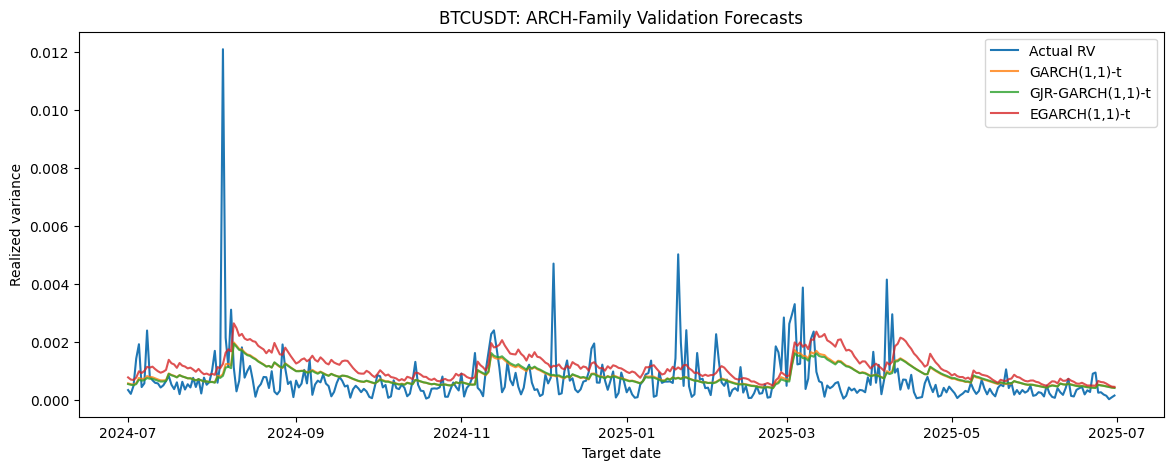

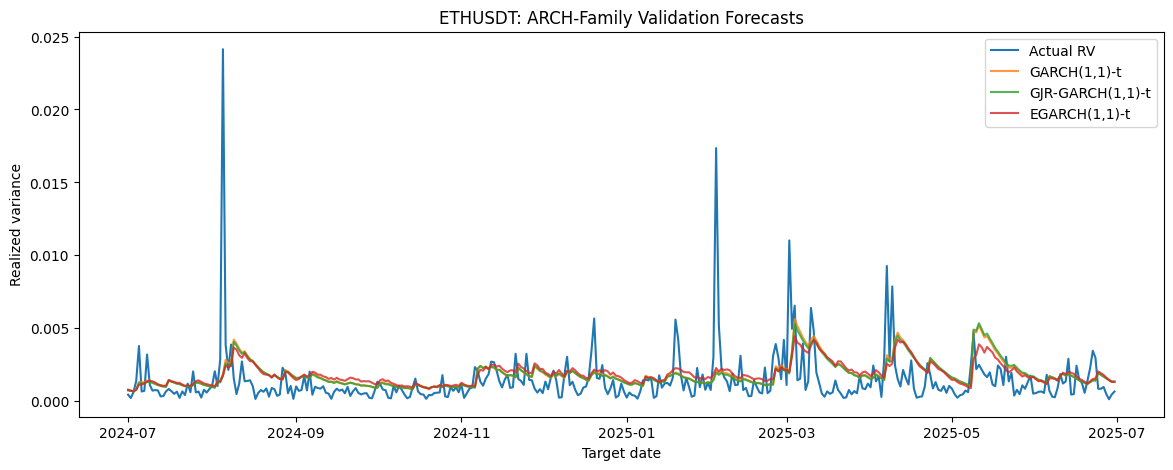

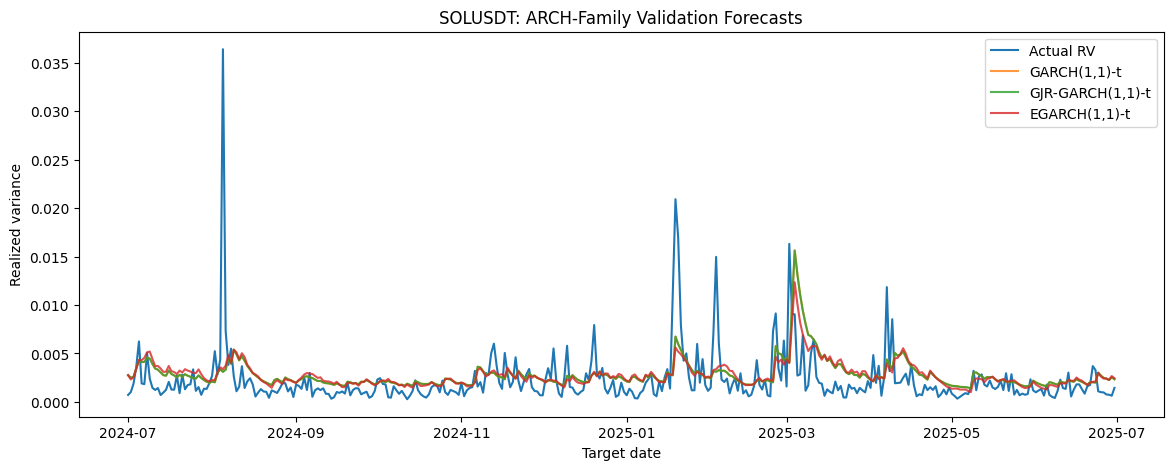

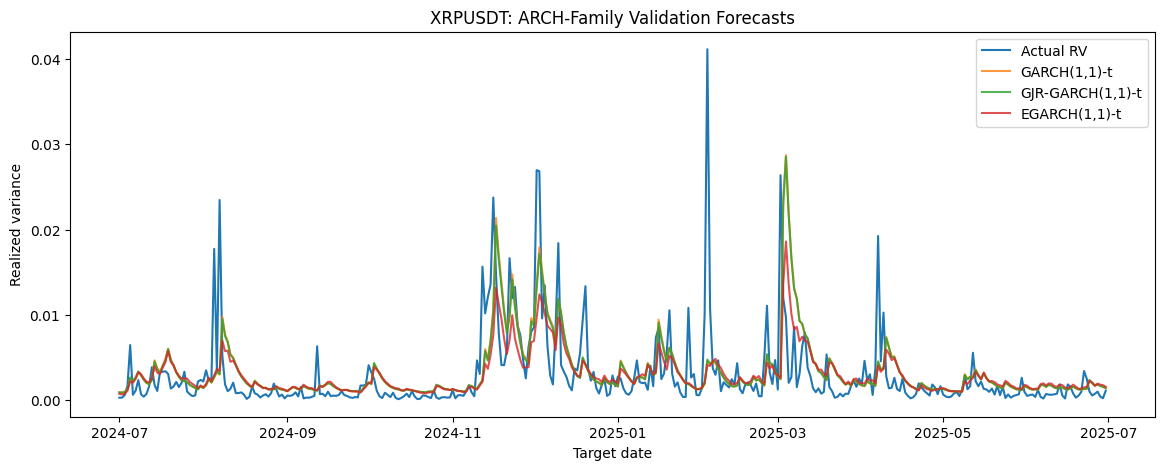

In [15]:
for symbol in ASSETS:
    plot_df = (
        arch_predictions_df.loc[
            arch_predictions_df[
                "symbol"
            ].eq(symbol)
        ]
        .sort_values(
            "target_date"
        )
    )

    actual_df = (
        plot_df[
            [
                "target_date",
                "actual_rv",
            ]
        ]
        .drop_duplicates(
            subset=["target_date"]
        )
    )

    plt.figure(
        figsize=(14, 5)
    )

    plt.plot(
        actual_df["target_date"],
        actual_df["actual_rv"],
        label="Actual RV"
    )

    for model_name in MODEL_SPECS:
        model_plot_df = (
            plot_df.loc[
                plot_df["model"].eq(
                    model_name
                )
            ]
        )

        plt.plot(
            model_plot_df[
                "target_date"
            ],
            model_plot_df[
                "predicted_rv"
            ],
            label=model_name,
            alpha=0.8
        )

    plt.xlabel("Target date")
    plt.ylabel("Realized variance")
    plt.title(
        f"{symbol}: ARCH-Family "
        "Validation Forecasts"
    )
    plt.legend()
    plt.show()


## 15. Final validation rule

Use validation QLIKE as the primary ranking metric. MAE and RMSE are complementary.

Do not use AIC or BIC to declare the final forecasting winner across model families.  
AIC and BIC describe in-sample likelihood fit for models estimated on the same return series; the final research question is out-of-sample realized-variance forecasting.

Do not open the test period in this notebook. After the best deep-learning and ARCH-family specifications are frozen, use one final notebook to evaluate both on the untouched test set.
